# ML-10 — Content Action Playbook

This notebook turns the validated Week-4 search-visibility rule into a human-reviewed action queue. It uses the March 1–21, 2026 decision snapshot; it does not use June’s sealed sample or future labels.


## 1. Ranked actions + reason codes

**Rule in plain words:** review pages that have at least 500 impressions, rank between 4 and 20, and have weighted CTR below 0.5%. Rank eligible pages by a transparent score that rewards reach and visibility while prioritizing lower CTR.

Every row gets one reason code and one action: `visible_low_ctr_position_opportunity` → `review_title_snippet_and_intent`. An archetype is a readable description of the situation, not an automatic diagnosis.


In [1]:
from pathlib import Path
import os,duckdb,pandas as pd,numpy as np
p=list((Path.home()/'.cache'/'huggingface'/'hub').rglob('fact_content_daily_performance/month=2026-03/data_0.parquet'))
if p: path=str(p[0])
else:
    try:
        from google.colab import userdata; token=userdata.get('HF_TOKEN')
    except Exception: token=os.environ.get('HF_TOKEN') or os.environ.get('HUGGINGFACE_HUB_TOKEN')
    if not token: raise RuntimeError('Set HF_TOKEN as a Colab Secret or environment variable; never paste it here.')
    from huggingface_hub import hf_hub_download; path=hf_hub_download('FlyRank/internship-warehouse','fact_content_daily_performance/month=2026-03/data_0.parquet',repo_type='dataset',token=token)
safe=path.replace(chr(39),chr(39)*2); con=duckdb.connect(); con.execute(f"CREATE VIEW march AS SELECT * FROM read_parquet('{safe}')")
d=con.sql("SELECT client_hash_id,content_hash_id,SUM(gsc_impressions) impressions_21d,SUM(gsc_clicks) clicks_21d,SUM(gsc_sum_position)/NULLIF(SUM(gsc_impressions),0) avg_position_21d FROM march WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-21' AND gsc_data_available IS TRUE GROUP BY 1,2 HAVING SUM(gsc_impressions)>0").df(); d['weighted_ctr_pct']=100*d.clicks_21d/d.impressions_21d
d['eligible']=(d.impressions_21d>=500)&d.avg_position_21d.between(4,20)&(d.weighted_ctr_pct<.5); d['baseline_action_score']=100*np.log1p(d.impressions_21d)+20*(21-d.avg_position_21d)-100*d.weighted_ctr_pct; d['reason_code']=np.where(d.eligible,'visible_low_ctr_position_opportunity','not_eligible'); d['action_label']=np.where(d.eligible,'review_title_snippet_and_intent','no_action'); d['archetype']=np.select([d.eligible&(d.impressions_21d>=10000),d.eligible&(d.avg_position_21d<=10),d.eligible],['high_reach_ctr_opportunity','visible_upper_page_ctr_opportunity','visible_low_ctr_opportunity'],'outside_rule'); queue=d[d.eligible].sort_values('baseline_action_score',ascending=False).reset_index(drop=True); queue['baseline_rank']=queue.index+1; print('Decision rows:',len(d),'eligible actions:',len(queue)); display(queue.head(10))


Decision rows: 162301 eligible actions: 23190


,client_hash_id,content_hash_id,impressions_21d,clicks_21d,avg_position_21d,weighted_ctr_pct,eligible,baseline_action_score,reason_code,action_label,archetype,baseline_rank
0,client_62f4a7e64f5e0096,content_b99ea6861864dea5,125082.0,245.0,4.448818,0.195872,True,1485.109777,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,1
1,client_73cda7b4e4f265ea,content_471d9cabce329a66,110663.0,275.0,4.544301,0.248502,True,1465.689142,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,2
2,client_62f4a7e64f5e0096,content_7c6373141eae744a,100270.0,57.0,5.813135,0.056847,True,1449.615838,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,3
3,client_73cda7b4e4f265ea,content_e578ac84778da489,74466.0,108.0,4.321234,0.145033,True,1440.883195,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,4
4,client_73cda7b4e4f265ea,content_f43118e089ecc69a,80299.0,129.0,4.853248,0.160650,True,1436.222563,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,5
5,client_73cda7b4e4f265ea,content_95ff62babbfac9c7,78330.0,155.0,4.581667,0.197881,True,1435.448449,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,6
6,client_73cda7b4e4f265ea,content_8e1334d6356668e3,63486.0,1.0,4.847573,0.001575,True,1428.750075,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,7
7,client_62f4a7e64f5e0096,content_1642f339bd6e7c8d,60075.0,22.0,4.696130,0.036621,True,1422.751885,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,8
8,client_62f4a7e64f5e0096,content_132dcd40faff1dc2,59100.0,78.0,4.228562,0.131980,True,1420.931108,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,9
9,client_e547b89c05043229,content_77276ad7a26f4905,55291.0,121.0,4.033007,0.218842,True,1409.493995,visible_low_ctr_position_opportunity,review_title_snippet_and_intent,high_reach_ctr_opportunity,10


## 2. Intended use and limits

**Intended user:** an SEO/content team lead. **Intended use:** choose a short list for human review of titles, snippets, and query intent. The score is a prioritization aid, not a promise of traffic lift.

**Archetype → action map:**

- `high_reach_ctr_opportunity` → review title/snippet first; estimate potential reach from impressions.
- `visible_upper_page_ctr_opportunity` → inspect SERP wording, intent match, and competing result types.
- `visible_low_ctr_opportunity` → review with lower urgency; confirm the signal is not sparse or branded demand.

**Limits:** the March panel is observational; CTR can be affected by brand intent, SERP features, seasonality, and tracking gaps. `gsc_data_available IS TRUE` defines the usable population. The rule does not identify cause, guarantee improvement, or generalize automatically to another month/client.


In [2]:
print('Archetype counts:'); display(queue.archetype.value_counts().rename_axis('archetype').to_frame('n')); print('Eligible weighted CTR range:',round(queue.weighted_ctr_pct.min(),3),'to',round(queue.weighted_ctr_pct.max(),3))


Archetype counts:


,n
archetype,
visible_upper_page_ctr_opportunity,16131
visible_low_ctr_opportunity,5979
high_reach_ctr_opportunity,1080


Eligible weighted CTR range: 0.0 to 0.5


## 3. Human review + the no-go list

Before acting, a reviewer checks: query intent and brand/navigation context; SERP features; whether the page is indexable and relevant; recent publishing/refresh history; and whether impressions are sufficient and stable. Record the reviewer’s decision and reason.

**No-go automation list:** never automatically rewrite or publish titles; change canonical tags, redirects, robots, or structured data; delete content; declare a page “bad”; or claim that an edit caused growth from this queue alone. Those actions require a qualified human and, for causal claims, an experiment or stronger design.


In [3]:
review_checklist=pd.DataFrame({'check':['intent/brand context','SERP features','indexability/relevance','recent changes','stable measurement'],'required_before_action':[True]*5}); display(review_checklist)


,check,required_before_action
0,intent/brand context,True
1,SERP features,True
2,indexability/relevance,True
3,recent changes,True
4,stable measurement,True


## 4. Monitoring / retrain triggers

Monitor the queue monthly on a fresh, time-separated period. Re-check base rate and Precision@10/20/50 against the current rule. Investigate drift when GSC availability changes, the score distribution shifts materially, or precision@20 falls below the agreed floor.

Suggested triggers: (1) availability changes by more than 10 percentage points; (2) median impressions or CTR shifts by more than 25% from the development snapshot; (3) precision@20 is below the observed March baseline for two consecutive periods; or (4) tracking/schema changes occur. Retrain or re-tune only after confirming the label and time windows remain aligned, then document the new version.


In [4]:
monitoring_triggers=pd.DataFrame({'trigger':['GSC availability change','distribution drift','precision@20 degradation','schema/tracking change'],'threshold':['>10 percentage points','>25% from March median','below March baseline for 2 periods','any confirmed change'],'response':['audit population','investigate seasonality/data quality','review rule/model and retrain if needed','pause and validate pipeline']}); display(monitoring_triggers)


,trigger,threshold,response
0,GSC availability change,>10 percentage points,audit population
1,distribution drift,>25% from March median,investigate seasonality/data quality
2,precision@20 degradation,below March baseline for 2 periods,review rule/model and retrain if needed
3,schema/tracking change,any confirmed change,pause and validate pipeline


## 5. Exports for the paper

The queue CSV is regenerated on every run and intentionally remains outside Git. A compact figure is saved under `work/figures/` so the paper can reuse it without exposing identifiers.


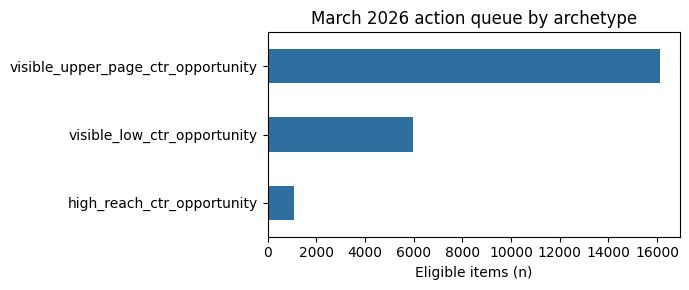

Wrote C:\Users\HP\OneDrive - Higher Education Commission\Desktop\summer2026\Flyrank\Flyrank_ML_Internship_Hamza\work\outputs\baseline_action_playbook_queue.csv
Wrote C:\Users\HP\OneDrive - Higher Education Commission\Desktop\summer2026\Flyrank\Flyrank_ML_Internship_Hamza\work\figures\w07_queue_archetypes.png


In [5]:
out=Path.cwd()/'work'/'outputs'; out.mkdir(parents=True,exist_ok=True); export_cols=['baseline_rank','archetype','reason_code','action_label','baseline_action_score','impressions_21d','clicks_21d','avg_position_21d','weighted_ctr_pct']; queue[export_cols].to_csv(out/'baseline_action_playbook_queue.csv',index=False)
figdir=Path.cwd()/'work'/'figures'; figdir.mkdir(parents=True,exist_ok=True)
import matplotlib.pyplot as plt
counts=queue.archetype.value_counts().sort_values(); ax=counts.plot.barh(figsize=(7,3),color='#2f6f9f'); ax.set_title('March 2026 action queue by archetype'); ax.set_xlabel('Eligible items (n)'); ax.set_ylabel(''); plt.tight_layout(); fig_path=figdir/'w07_queue_archetypes.png'; plt.savefig(fig_path,dpi=160); plt.show(); print('Wrote',out/'baseline_action_playbook_queue.csv'); print('Wrote',fig_path)


## 6. Self-check

- [x] Ranked actions, one reason code, one action label, and archetype mapping
- [x] Intended use, limits, cost/value logic, and human review rules
- [x] Explicit no-go automation list
- [x] Monitoring and retrain triggers
- [x] Queue and paper-ready figure exported

**Cost/value thinking:** start with the highest-reach eligible pages because reviewer time is limited; use the score to order work, not to estimate guaranteed revenue. A small pilot with documented review outcomes is the safe next step.
